In [1]:
# Environment verification
import sys
import torch
import torchvision

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.10.0 (default, Nov 24 2025, 19:41:35) [GCC 13.3.0]
Torch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
CUDA available: True


In [11]:
from pathlib import Path
from PIL import Image

train_dir = Path("data/LibVision-2/train")
images_dir = train_dir / "images"
labels_dir = train_dir / "labels"

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts])

pairs = []
missing_labels = []

for img_path in image_paths:
    label_path = labels_dir / f"{img_path.stem}.txt"
    if not label_path.exists():
        missing_labels.append(img_path)
        continue

    with label_path.open("r") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    labels = []
    for ln in lines:
        parts = ln.split()
        if not parts:
            continue
        cls_id = int(float(parts[0]))
        coords = [float(x) for x in parts[1:]]
        labels.append({"class": cls_id, "coords": coords})

    pairs.append((img_path, labels))

print("Num images:", len(image_paths))
print("Num images with labels:", len(pairs))
print("Num missing labels:", len(missing_labels))
if missing_labels:
    print("First missing label image:", missing_labels[0])

for i, (img_path, labels) in enumerate(pairs[:3]):
    with Image.open(img_path) as im:
        w, h = im.size
    print(f"[{i}] {img_path.name} ({w}x{h}) -> {len(labels)} label lines")
    if labels:
        print("  first label class:", labels[0]["class"], "num coords:", len(labels[0]["coords"]))


Num images: 769
Num images with labels: 769
Num missing labels: 0
[0] 00612d433b7b671909ba1a2da353ba2b_jpg.rf.e928dd38c7d108f595359c817a6182cd.jpg (640x640) -> 37 label lines
  first label class: 0 num coords: 22
[1] 012163a70536012241cc60a8febc4a8e_jpg.rf.e08423f4cb512b23b43ba93eb0067b14.jpg (640x640) -> 13 label lines
  first label class: 0 num coords: 10
[2] 0233e36c58f1823ac3ab520b6616fc59_jpg.rf.b7f01d68f7bc8c5d3f93b12d4ab99e88.jpg (640x640) -> 9 label lines
  first label class: 0 num coords: 28


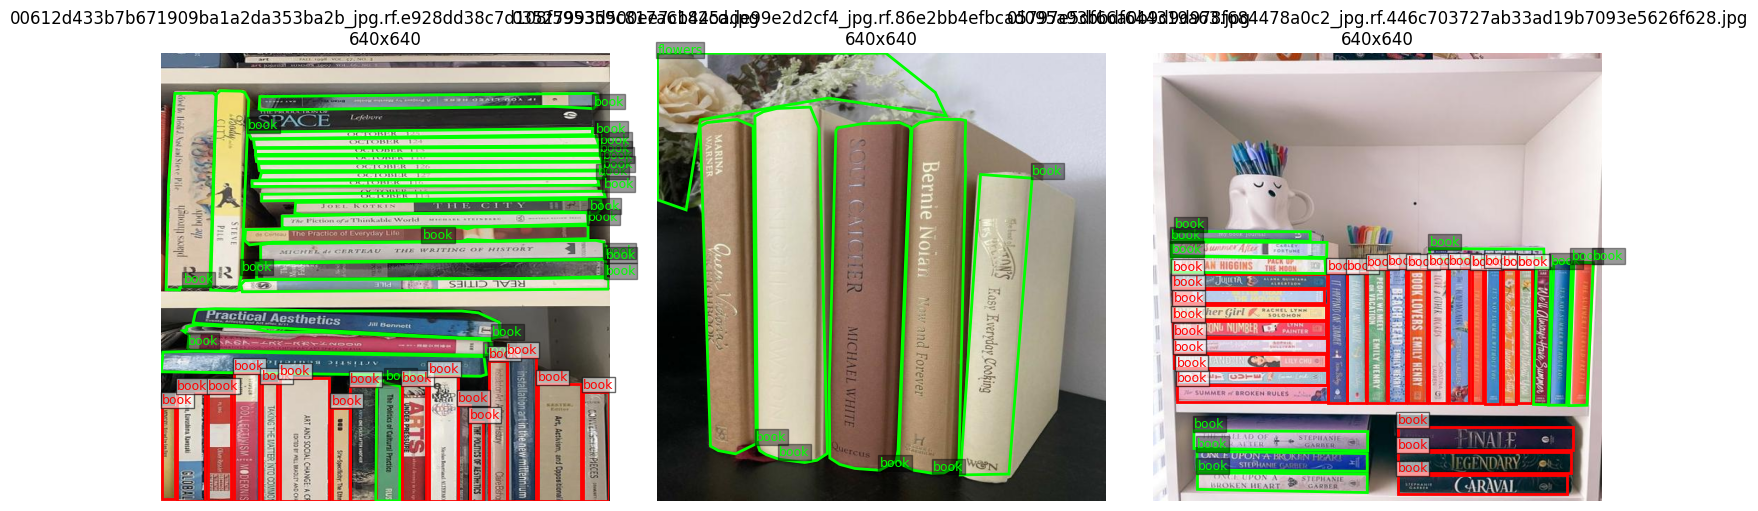

In [12]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

train_dir = Path("data/LibVision-2/train")
images_dir = train_dir / "images"
labels_dir = train_dir / "labels"

def _load_class_names(data_yaml_path: Path):
    if not data_yaml_path.exists():
        return None
    names = []
    in_names = False
    for raw in data_yaml_path.read_text().splitlines():
        line = raw.strip()
        if not line:
            continue
        if line.startswith("names:"):
            in_names = True
            continue
        if in_names:
            if line.startswith("-"):
                names.append(line[1:].strip())
            else:
                break
    return names if names else None

class_names = _load_class_names(Path("data/LibVision-2/data.yaml"))

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, [0, 5, 10]):
    img_path = image_paths[idx]
    label_path = labels_dir / f"{img_path.stem}.txt"

    with Image.open(img_path) as im:
        img = im.convert("RGB")
    w, h = img.size

    ax.imshow(img)
    ax.set_title(f"{img_path.name}\n{w}x{h}")

    if label_path.exists():
        for raw in label_path.read_text().splitlines():
            raw = raw.strip()
            if not raw:
                continue

            parts = raw.split()
            cls_id = int(float(parts[0]))
            coords = [float(x) for x in parts[1:]]

            label = str(cls_id)
            if class_names is not None and 0 <= cls_id < len(class_names):
                label = class_names[cls_id]

            # YOLO bbox: cls cx cy w h (normalized)
            if len(coords) == 4:
                cx, cy, bw, bh = coords
                x0 = (cx - bw / 2.0) * w
                y0 = (cy - bh / 2.0) * h
                rect = patches.Rectangle((x0, y0), bw * w, bh * h,
                                         fill=False, edgecolor="red", linewidth=2)
                ax.add_patch(rect)
                ax.text(x0, max(0, y0 - 5), label, color="red", fontsize=9,
                        bbox=dict(facecolor="white", alpha=0.6, pad=1))

            # Polygon segmentation: cls x1 y1 x2 y2 ... (normalized)
            elif len(coords) >= 6 and len(coords) % 2 == 0:
                pts = []
                for x, y in zip(coords[0::2], coords[1::2]):
                    pts.append((x * w, y * h))
                poly = patches.Polygon(pts, closed=True, fill=False, edgecolor="lime", linewidth=2)
                ax.add_patch(poly)
                x0, y0 = pts[0]
                ax.text(x0, max(0, y0 - 5), label, color="lime", fontsize=9,
                        bbox=dict(facecolor="black", alpha=0.4, pad=1))

    ax.axis("off")

plt.tight_layout()
plt.show()


In [13]:
import torch
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models import ResNet18_Weights

# Single-class detection: book only
class_names = ["book"]
NUM_CLASSES = 2  # background + book

backbone = resnet_fpn_backbone(backbone_name="resnet18", weights=ResNet18_Weights.DEFAULT)
model = FasterRCNN(backbone, num_classes=NUM_CLASSES)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Classes:", class_names)
print("NUM_CLASSES (incl background):", NUM_CLASSES)
print("Device:", device)


Classes: ['book']
NUM_CLASSES (incl background): 2
Device: cuda


In [14]:
import torch
import torch.optim as optim
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor


train_dir = Path("data/LibVision-2/train")
images_dir = train_dir / "images"
labels_dir = train_dir / "labels"

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts])

BOOK_CLASS_ID = 0  # in data.yaml, 'book' is the first class

def _yolo_line_to_box(coords, w, h):
    if len(coords) == 4:
        cx, cy, bw, bh = coords
        x1 = (cx - bw / 2.0) * w
        y1 = (cy - bh / 2.0) * h
        x2 = (cx + bw / 2.0) * w
        y2 = (cy + bh / 2.0) * h
        return [x1, y1, x2, y2]

    if len(coords) >= 6 and len(coords) % 2 == 0:
        xs = coords[0::2]
        ys = coords[1::2]
        x1 = min(xs) * w
        y1 = min(ys) * h
        x2 = max(xs) * w
        y2 = max(ys) * h
        return [x1, y1, x2, y2]

    return None


class LibVisionBookDetection(Dataset):
    def __init__(self, image_paths, labels_dir, transforms=None):
        self.image_paths = list(image_paths)
        self.labels_dir = Path(labels_dir)
        self.transforms = transforms or ToTensor()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = self.labels_dir / f"{img_path.stem}.txt"

        with Image.open(img_path) as im:
            img = im.convert("RGB")
        w, h = img.size

        boxes, labels = [], []
        if label_path.exists():
            for raw in label_path.read_text().splitlines():
                raw = raw.strip()
                if not raw:
                    continue
                parts = raw.split()
                cls_id = int(float(parts[0]))
                if cls_id != BOOK_CLASS_ID:
                    continue

                coords = [float(x) for x in parts[1:]]
                box = _yolo_line_to_box(coords, w, h)
                if box is None:
                    continue

                x1, y1, x2, y2 = box
                if x2 <= x1 or y2 <= y1:
                    continue

                boxes.append([x1, y1, x2, y2])
                labels.append(1)  # book

        img_t = self.transforms(img)
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
        }
        return img_t, target


def detection_collate(batch):
    images, targets = [], []
    for img, target in batch:
        if target["boxes"].numel() == 0:
            continue
        images.append(img)
        targets.append(target)
    return images, targets


dataset = LibVisionBookDetection(image_paths, labels_dir)
trainloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=detection_collate)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=5e-4)

num_epochs = 5

print("Dataset size:", len(dataset))


Dataset size: 769


In [15]:
import time
import torch

model.train()

for epoch in range(num_epochs):
    t0 = time.time()
    running_loss = 0.0
    num_steps = 0

    for step, (images, targets) in enumerate(trainloader):
        # collate_fn may skip images with no boxes -> can produce an empty batch
        if len(images) == 0:
            continue

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(v for v in loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_steps += 1

        if step % 25 == 0:
            loss_items = {k: float(v.detach().cpu()) for k, v in loss_dict.items()}
            print(f"epoch={epoch+1} step={step} loss={loss.item():.4f} "
                  f"cls={loss_items.get('loss_classifier', 0.0):.4f} "
                  f"box={loss_items.get('loss_box_reg', 0.0):.4f} "
                  f"obj={loss_items.get('loss_objectness', 0.0):.4f} "
                  f"rpn={loss_items.get('loss_rpn_box_reg', 0.0):.4f}")

    avg_loss = running_loss / max(1, num_steps)
    dt = time.time() - t0
    print(f"Epoch {epoch+1}/{num_epochs} avg_loss={avg_loss:.4f} steps={num_steps} time={dt:.1f}s")


epoch=1 step=0 loss=2.0584 cls=0.7381 box=0.0043 obj=0.6996 rpn=0.6164
epoch=1 step=25 loss=0.8820 cls=0.2340 box=0.2136 obj=0.1936 rpn=0.2408
epoch=1 step=50 loss=0.7312 cls=0.1645 box=0.1676 obj=0.1059 rpn=0.2932
epoch=1 step=75 loss=1.2037 cls=0.3133 box=0.4246 obj=0.1544 rpn=0.3113
epoch=1 step=100 loss=1.2643 cls=0.3618 box=0.4297 obj=0.2212 rpn=0.2516
epoch=1 step=125 loss=1.1066 cls=0.2214 box=0.2956 obj=0.0979 rpn=0.4917
epoch=1 step=150 loss=1.3477 cls=0.1358 box=0.2331 obj=0.2625 rpn=0.7163
epoch=1 step=175 loss=0.9464 cls=0.1802 box=0.2691 obj=0.1183 rpn=0.3788
Epoch 1/5 avg_loss=1.0667 steps=193 time=34.1s
epoch=2 step=0 loss=0.9979 cls=0.2022 box=0.3852 obj=0.0948 rpn=0.3157
epoch=2 step=25 loss=1.1414 cls=0.2082 box=0.4660 obj=0.1112 rpn=0.3560
epoch=2 step=50 loss=0.6907 cls=0.1493 box=0.2111 obj=0.0841 rpn=0.2462
epoch=2 step=75 loss=0.8604 cls=0.1780 box=0.2953 obj=0.0613 rpn=0.3258
epoch=2 step=100 loss=0.4496 cls=0.1116 box=0.1998 obj=0.0277 rpn=0.1104
epoch=2 step=1

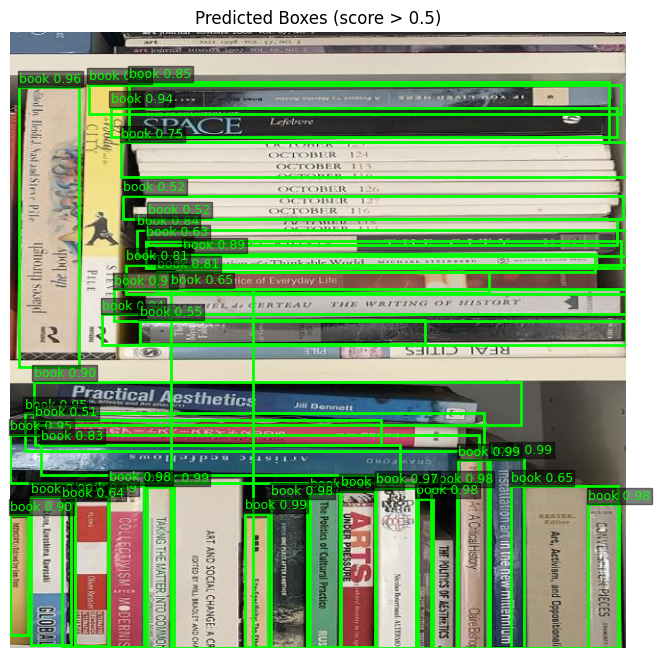

In [16]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

model.eval()

img, _ = dataset[0]
with torch.no_grad():
    prediction = model([img.to(device)])

pred = prediction[0]
boxes = pred["boxes"].detach().cpu().numpy()
labels = pred["labels"].detach().cpu().numpy()
scores = pred["scores"].detach().cpu().numpy()

score_thresh = 0.5

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img.permute(1, 2, 0).cpu())

for box, label, score in zip(boxes, labels, scores):
    if score < score_thresh:
        continue

    name = "book" if label == 1 else "background"
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             fill=False, edgecolor="lime", linewidth=2)
    ax.add_patch(rect)
    ax.text(x1, max(0, y1 - 5), f"{name} {score:.2f}", color="lime", fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5, pad=1))

ax.set_title(f"Predicted Boxes (score > {score_thresh})")
ax.axis("off")
plt.show()


In [17]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader


def box_iou(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x11, y11, x12, y12 = boxes1[:, 0], boxes1[:, 1], boxes1[:, 2], boxes1[:, 3]
    x21, y21, x22, y22 = boxes2[:, 0], boxes2[:, 1], boxes2[:, 2], boxes2[:, 3]

    xa = torch.maximum(x11[:, None], x21[None, :])
    ya = torch.maximum(y11[:, None], y21[None, :])
    xb = torch.minimum(x12[:, None], x22[None, :])
    yb = torch.minimum(y12[:, None], y22[None, :])

    inter = torch.clamp(xb - xa, min=0) * torch.clamp(yb - ya, min=0)
    area1 = torch.clamp(x12 - x11, min=0) * torch.clamp(y12 - y11, min=0)
    area2 = torch.clamp(x22 - x21, min=0) * torch.clamp(y22 - y21, min=0)
    union = area1[:, None] + area2[None, :] - inter

    return torch.where(union > 0, inter / union, torch.zeros_like(inter))


def voc_ap(rec: np.ndarray, prec: np.ndarray) -> float:
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))

    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))
    return ap


def evaluate_ap50_book(model, dataset, device, score_thresh=0.05, iou_thresh=0.5):
    model.eval()

    det_scores = []
    det_tp = []
    gt_total = 0

    loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=detection_collate)

    with torch.no_grad():
        for images, targets in loader:
            if len(images) == 0:
                continue

            img = images[0].to(device)
            target = targets[0]
            gt_boxes = target["boxes"].to(device)
            gt_labels = target["labels"].to(device)

            gt_boxes = gt_boxes[gt_labels == 1]
            gt_total += int(gt_boxes.shape[0])

            preds = model([img])[0]
            pred_boxes = preds["boxes"].to(device)
            pred_labels = preds["labels"].to(device)
            pred_scores = preds["scores"].to(device)

            keep = (pred_scores >= score_thresh) & (pred_labels == 1)
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]

            if pred_boxes.numel() == 0:
                continue

            order = torch.argsort(pred_scores, descending=True)
            pred_boxes = pred_boxes[order]
            pred_scores = pred_scores[order]

            matched = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool, device=device)
            ious = box_iou(pred_boxes, gt_boxes)

            for j in range(pred_boxes.shape[0]):
                det_scores.append(float(pred_scores[j].detach().cpu()))

                if gt_boxes.numel() == 0:
                    det_tp.append(0)
                    continue

                best_iou, best_gt = torch.max(ious[j], dim=0)
                if float(best_iou) >= iou_thresh and not bool(matched[best_gt]):
                    matched[best_gt] = True
                    det_tp.append(1)
                else:
                    det_tp.append(0)

    scores = np.array(det_scores, dtype=np.float32)
    tps = np.array(det_tp, dtype=np.int32)

    if scores.size == 0:
        ap = 0.0
    else:
        order = np.argsort(-scores)
        tps = tps[order]
        fps = 1 - tps

        tp_cum = np.cumsum(tps)
        fp_cum = np.cumsum(fps)

        rec = tp_cum / max(1, gt_total)
        prec = tp_cum / np.maximum(1, (tp_cum + fp_cum))

        ap = voc_ap(rec, prec)

    print(f"Book AP@0.5 (IoU={iou_thresh}, score>={score_thresh}): {ap:.4f} (GT={gt_total})")
    return ap


valid_dir = Path("data/LibVision-2/valid")
valid_images_dir = valid_dir / "images"
valid_labels_dir = valid_dir / "labels"

valid_image_paths = sorted([p for p in valid_images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts])
valid_dataset = LibVisionBookDetection(valid_image_paths, valid_labels_dir)

_ = evaluate_ap50_book(model, valid_dataset, device, score_thresh=0.05, iou_thresh=0.5)


Book AP@0.5 (IoU=0.5, score>=0.05): 0.9321 (GT=1658)


Display a few images of predicted (green) and ground truth (red) spine detections

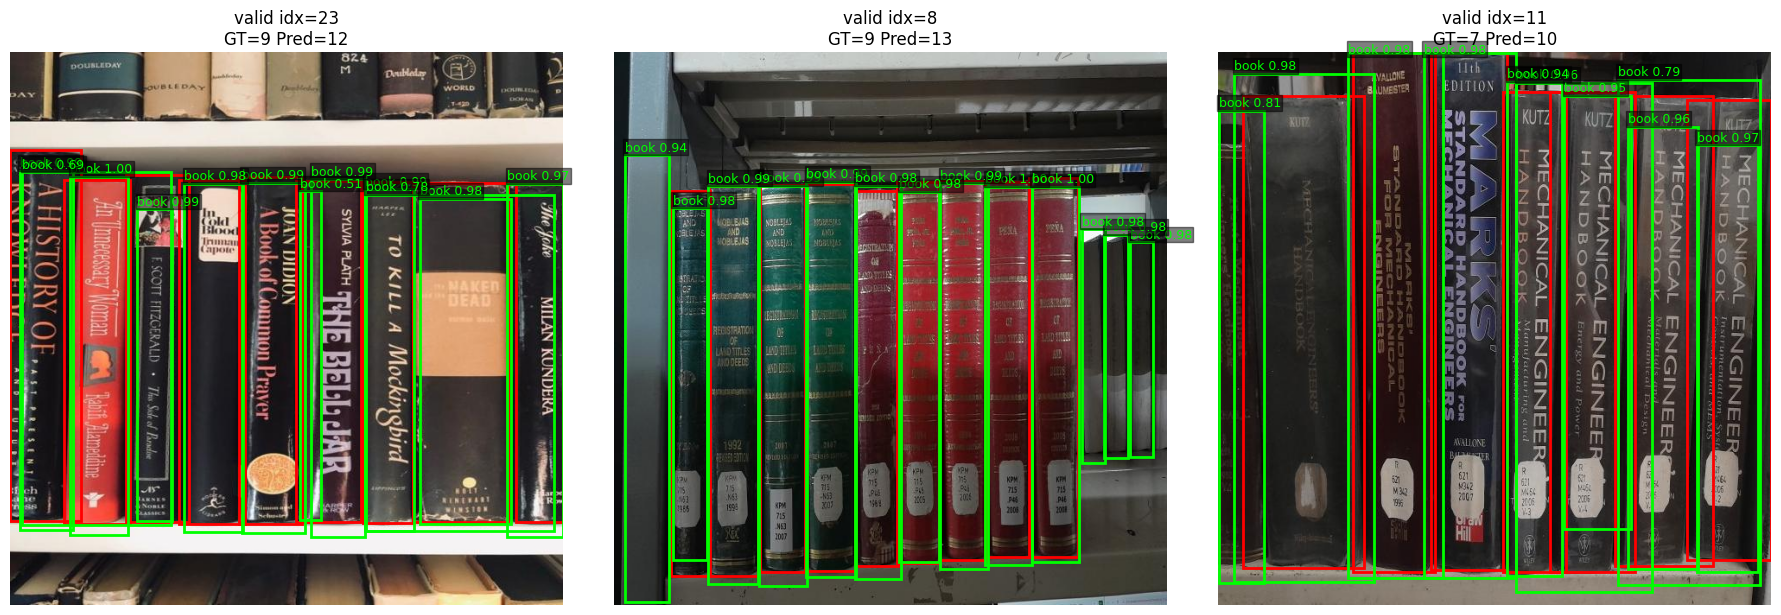

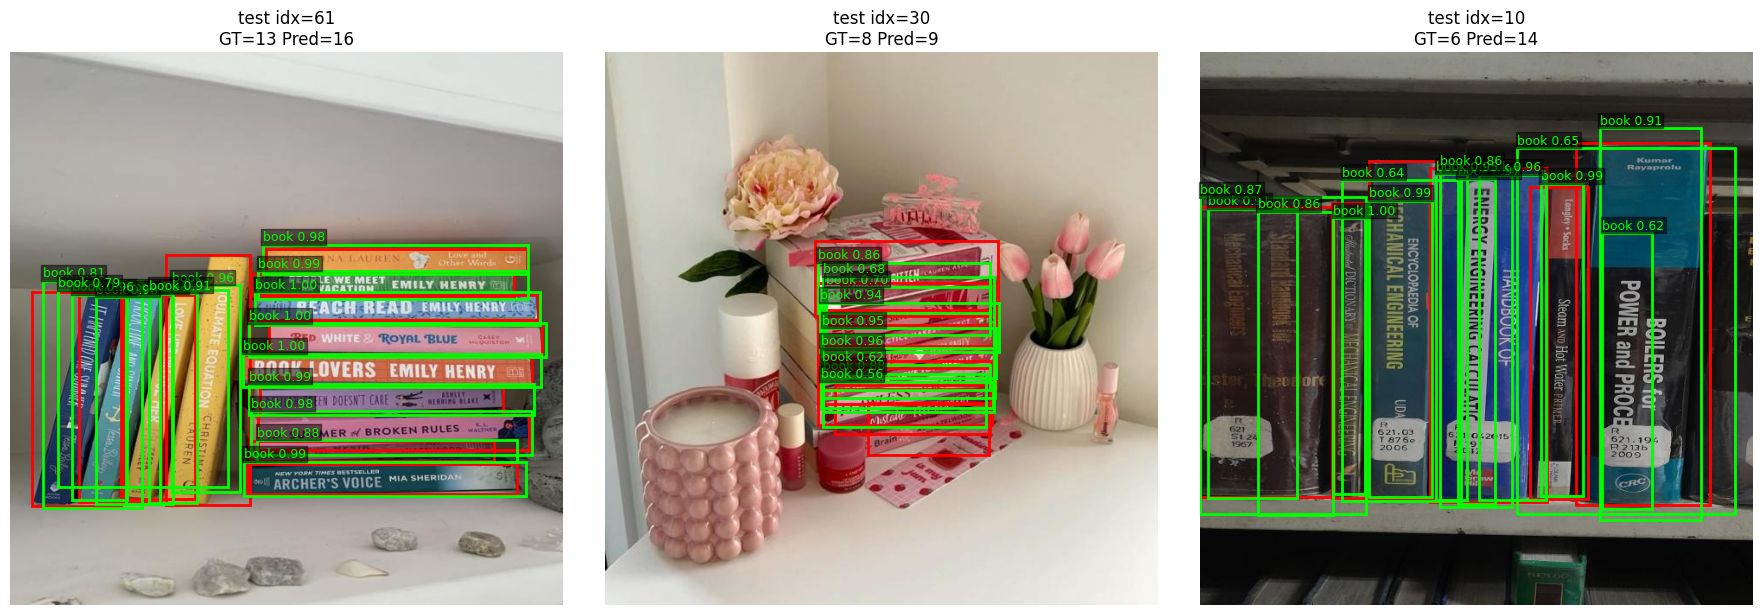

In [18]:
import random
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path


def _viz_split(split_name: str, n: int = 3, score_thresh: float = 0.5, seed: int = 0):
    split_dir = Path(f"data/LibVision-2/{split_name}")
    split_images_dir = split_dir / "images"
    split_labels_dir = split_dir / "labels"

    split_image_paths = sorted([p for p in split_images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts])
    split_dataset = LibVisionBookDetection(split_image_paths, split_labels_dir)

    rng = random.Random(seed)
    idxs = list(range(len(split_dataset)))
    rng.shuffle(idxs)
    idxs = idxs[:n]

    model.eval()

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, idxs):
        img, target = split_dataset[idx]

        with torch.no_grad():
            pred = model([img.to(device)])[0]

        ax.imshow(img.permute(1, 2, 0).cpu())

        gt_boxes = target["boxes"].cpu().numpy()
        for (x1, y1, x2, y2) in gt_boxes:
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     fill=False, edgecolor="red", linewidth=2)
            ax.add_patch(rect)

        boxes = pred["boxes"].detach().cpu().numpy()
        scores = pred["scores"].detach().cpu().numpy()
        labels = pred["labels"].detach().cpu().numpy()

        kept = 0
        for (x1, y1, x2, y2), s, lab in zip(boxes, scores, labels):
            if lab != 1 or s < score_thresh:
                continue
            kept += 1
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     fill=False, edgecolor="lime", linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, max(0, y1 - 5), f"book {s:.2f}", color="lime", fontsize=9,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))

        ax.set_title(f"{split_name} idx={idx}\nGT={len(gt_boxes)} Pred={kept}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


_viz_split("valid", n=3, score_thresh=0.5, seed=0)
_viz_split("test", n=3, score_thresh=0.5, seed=1)
